In [1]:
import numpy as np
import matplotlib as mpl
import glob
import os
import matplotlib.pyplot as plt
import numpy.ma as ma
from scipy import stats
import xarray as xr
import commondefs as myF
plt.rcParams.update({'font.size': 12})

In [2]:
mydir = '../processed_netcdf/'
nm = 12
othercolours = np.append(plt.cm.tab20(np.linspace(0,1,20)),plt.cm.tab20(np.linspace(0,1,20)),axis=0)

In [3]:
model_ds = xr.open_dataset(mydir+'processed_CMIP6_sia_historical_r1.nc').sel(year=slice('1979','2014'))
obs_ds =  xr.open_dataset(mydir+'processed_OBS_sia_1979-2018.nc').sel(year=slice('1979','2014'))
ensemble_ds = xr.open_dataset('../processed_netcdf/processed_CMIP6_sia_historical_allr.nc').sel(year=slice('1979','2014'))

In [4]:
obs_ds = myF.add_trend_stats_to_ds (obs_ds, obs_ds.sia_sh, 'sia_sh')

best_fit = np.zeros(obs_ds.sia_sh.shape)
for y, year in enumerate(obs_ds.year.values):
    best_fit[:,y,:] = year*obs_ds.sia_sh_slope + obs_ds.sia_sh_intercept

obs_ds['sia_sh_detrended'] = xr.DataArray(obs_ds.sia_sh - best_fit, dims = ['name','year','month'])

In [5]:
model_ds = myF.add_trend_stats_to_ds (model_ds, model_ds.sia_sh, 'sia_sh')
    
best_fit = np.zeros(model_ds.sia_sh.shape)
for y, year in enumerate(model_ds.year.values):
    best_fit[:,y,:] = year*model_ds.sia_sh_slope + model_ds.sia_sh_intercept

model_ds['sia_sh_detrended'] = xr.DataArray(model_ds.sia_sh - best_fit, dims = ['name','year','month'])
  

In [6]:
# compute IV from piControl
myfiles = [mydir+'/piControl/CMIP6_sia_sh/'+f for f in sorted(os.listdir(mydir+'/piControl/CMIP6_sia_sh/'))]
ivpc = {}
for n,file in enumerate(myfiles):
    ds = xr.open_dataset(file,decode_times=False)
    if len(ds.sia.shape) ==3:
        sia = ds.sia[:,0,0].values
    else:
        sia = ds.sia.values

    if file.split('_')[5] in [f.strip().split('_')[0] for f in model_ds.name.values]:
        if len(sia)>nm*40:
            ny = int(len(sia)/nm)
            sia_ym = np.reshape(sia[:ny*nm],(ny,nm))
            ivpc[file.split('_')[5]] = [np.std(sia_ym[:,8]),np.std(sia_ym[:,1])]


print('SH February max IV ',max([ivpc[f][1] for f in ivpc]))
print('SH September max IV ',max([ivpc[f][0] for f in ivpc]))
print('CanESM5 SH Sep and Feb',ivpc['CanESM5'])
print(ivpc)

SH February max IV  2.8035698
SH September max IV  2.1816115
CanESM5 SH Sep and Feb [0.6569961, 0.79445106]
{'ACCESS-CM2': [0.5715134, 0.30865204], 'ACCESS-ESM1-5': [0.639414, 0.37257448], 'AWI-CM-1-1-MR': [0.6232692, 0.5118577], 'CAMS-CSM1-0': [1.0939801, 0.015217716], 'CESM2-WACCM': [0.4433896, 0.5162283], 'CESM2': [0.4719368, 0.4670398], 'CNRM-ESM2-1': [0.8923781, 0.3682148], 'CanESM5': [0.6569961, 0.79445106], 'E3SM-1-0': [2.1816115, 2.8035698], 'EC-Earth3-Veg': [0.8569095, 0.23789796], 'EC-Earth3': [0.7834749, 0.2172861], 'GFDL-CM4': [0.8787969, 0.32874686], 'GFDL-ESM4': [1.577789, 0.33688307], 'GISS-E2-1-G-CC': [0.77584136, 0.40665352], 'GISS-E2-1-G': [0.68882954, 0.46514085], 'GISS-E2-1-H': [1.3913691, 0.6961075], 'HadGEM3-GC31-LL': [0.66309935, 0.44443357], 'INM-CM4-8': [0.5754425, 0.37683937], 'IPSL-CM6A-LR': [0.68506444, 0.49517474], 'MIROC-ES2L': [0.27496716, 0.017485907], 'MIROC6': [0.33392593, 0.01916828], 'MPI-ESM1-2-HR': [1.404987, 0.29446715], 'MRI-ESM2-0': [0.55419296,

'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches

'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches

Bootstrap 9 0.33732582594615657
NASA Team 9 0.3500462612265324
OSISAF 9 0.3472518677349267


'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches

'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches

Bootstrap 2 0.27445659385298066
NASA Team 2 0.2554764318741288
OSISAF 2 0.2551555155112506


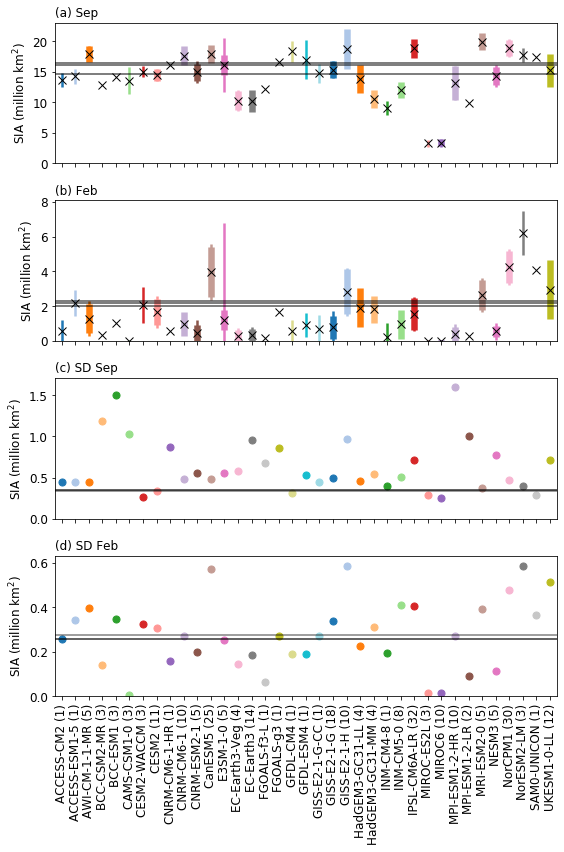

In [16]:
plt.rcParams.update({'font.size': 12})

fig, ax = plt.subplots(figsize=(8,12))

for p, month in enumerate([9,2]):
    ax = plt.subplot(4,1,p+1)
    for o,ob in enumerate(obs_ds.name.values):  
        ax.axhline(y=obs_ds['sia_sh'].mean(dim='year').sel(month=month).sel(name=ob),c='black',alpha=.5,linewidth=2.)
    
    labels = []
    for m,model in enumerate(model_ds.name.values):
        mmean = model_ds['sia_sh'].sel(name=model).sel(month=month).mean(dim='year')

        # from pre-industrial control
        yerr = 0.
        if model.split('_')[0] in ivpc:
            yerr = 2.*ivpc[model.split('_')[0]][p]

        markers, caps, bars = ax.errorbar(m,mmean,yerr = yerr, linewidth=2.5,ecolor=othercolours[m])
        [bar.set_alpha(1.0) for bar in bars]

        # from individual model ensemble
        members = [f for f in ensemble_ds.name.values if model.split('_')[0]+'_' in f]
        yerre = 0.
        if len(members) >= 4:
            yerre = 2.*np.std(ensemble_ds['sia_sh'].sel(name=members).sel(month=month).values.flatten())

        markers, caps, bars = ax.errorbar(m,mmean,yerr = yerre,fmt='x',linewidth=6.5,ecolor=othercolours[m],markerfacecolor='black',
                   markeredgecolor='black',markersize=8)

        [bar.set_alpha(1.0) for bar in bars]
        labels.append(model.split('_')[0]+' ('+str(len(members))+')')
    
    ax.set_xticks(np.arange(len(model_ds.name)))
    ax.set_xticklabels(['']*len(model_ds.name))
    ax.set_ylabel('SIA (million km$^2$)')
    ax.set_title(myF.alphabet[p]+' '+myF.months[month-1],loc='left',fontsize=12)
    ax.set_ylim(bottom=0.)
    ax.set_xlim([-0.5,len(model_ds.name.values)-.5])
    
        
for p, month in enumerate([9,2]):
    ax = plt.subplot(4,1,2+p+1)
    for o,ob in enumerate(obs_ds.name.values):  
        ax.axhline(y=obs_ds.sia_sh_detrended.std(dim='year').sel(month=month).sel(name=ob),c='black',alpha=.5)
        print(ob,month,obs_ds.sia_sh_detrended.std(dim='year').sel(month=month).sel(name=ob).values)
    for m,model in enumerate(model_ds.name.values):
        ax.scatter(m,model_ds.sia_sh_detrended.sel(name=model).std(dim='year').sel(month=month).values, s=50,
                   marker='o',c=othercolours[m])
        
    ax.set_ylabel('SIA (million km$^2$)')
    ax.set_title(myF.alphabet[p+2]+' SD '+myF.months[month-1],loc='left',fontsize=12)
    ax.set_xticks(np.arange(len(model_ds.name)))
    ax.set_xticklabels(['']*len(model_ds.name.values))
    if p==1:
        ax.set_xticklabels(labels,rotation='vertical',fontsize=12) 
    ax.set_xlim([-0.5,len(model_ds.name.values)-.5])
    ax.set_ylim(bottom=0.)

plt.tight_layout()
#fig.savefig(savedir+'/sia_mean_bymodel_1979-2014',bbox_inches='tight',dpi=600)
plt.show(); plt.close()